<a href="https://colab.research.google.com/github/danielpomboza6/AA_U2_T1_Numpy_Pomboza_Daniel/blob/main/STV_Semana08_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STV - Semana 08  
## Unidad 2 · Tema 2.2: Manipulación avanzada de arrays con NumPy

**Asignatura:** Programación II  
**Tema de la sesión:** unión, separación, `np.newaxis`, lectura con `np.genfromtxt`, KNN vectorizado e imágenes como matrices.

### Propósito de la sesión

Aplicar técnicas avanzadas de manipulación de arreglos NumPy para construir soluciones algorítmicas eficientes en problemas de ciencia de datos.

### Resultados esperados

Al finalizar este STV, el estudiante será capaz de:

- Unir arrays usando `concatenate`, `vstack`, `hstack`, `stack` y `column_stack`.
- Separar matrices en variables, etiquetas y subconjuntos.
- Usar `np.newaxis` para construir operaciones vectorizadas.
- Implementar una variante de KNN usando distancias vectorizadas.
- Leer datos desde archivos CSV con `np.genfromtxt`.
- Procesar una imagen como matriz NumPy.
- Construir un mini algoritmo adicional de detección de anomalías.

## 0. Importación de librerías

En esta sesión trabajaremos únicamente con NumPy.  
También usaremos `matplotlib` solo para visualizar matrices como imágenes.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=3, suppress=True)

# 1. Unión de arrays

En ciencia de datos, muchas veces los datos llegan separados por variable, sensor o fuente.  
El objetivo es convertir esos arrays separados en una estructura matricial útil para algoritmos.

## Ejercicio guiado 1: integración de sensores ambientales

Se tienen tres sensores: temperatura, humedad y presión.  
Construya una matriz donde:

- cada fila represente una medición;
- cada columna represente una variable;
- las columnas sean: temperatura, humedad y presión.

In [41]:
temperatura = np.array([18.5, 19.2, 20.1, 21.0, 20.5])
humedad = np.array([70, 68, 65, 60, 63])
presion = np.array([1012, 1011, 1010, 1009, 1011])

print("temperatura:", temperatura.shape)
print("humedad:", humedad.shape)
print("presion:", presion.shape)

temperatura: (5,)
humedad: (5,)
presion: (5,)


### 1.1. Unión con `np.column_stack`

`column_stack` es muy útil cuando se tienen varios vectores y se desea formar una matriz por columnas.

In [42]:
sensores = np.column_stack([temperatura, humedad, presion])

print("Matriz de sensores:")
print(sensores)
print("Forma:", sensores.shape)

Matriz de sensores:
[[  18.5   70.  1012. ]
 [  19.2   68.  1011. ]
 [  20.1   65.  1010. ]
 [  21.    60.  1009. ]
 [  20.5   63.  1011. ]]
Forma: (5, 3)


### 1.2. Unión con `np.stack`

`stack` crea una nueva dimensión.  
Por eso es importante controlar el eje con `axis`.

In [43]:
stack_axis_0 = np.stack([temperatura, humedad, presion], axis=0)


print("np.stack(..., axis=0)")
print(stack_axis_0)
print("Forma:", stack_axis_0.shape)



np.stack(..., axis=0)
[[  18.5   19.2   20.1   21.    20.5]
 [  70.    68.    65.    60.    63. ]
 [1012.  1011.  1010.  1009.  1011. ]]
Forma: (3, 5)


In [44]:
stack_axis_0 = np.vstack([temperatura, humedad, presion])


print("np.stack(..., axis=0)")
print(stack_axis_0)
print("Forma:", stack_axis_0.shape)

np.stack(..., axis=0)
[[  18.5   19.2   20.1   21.    20.5]
 [  70.    68.    65.    60.    63. ]
 [1012.  1011.  1010.  1009.  1011. ]]
Forma: (3, 5)


In [45]:
stack_axis_1 = np.stack([temperatura, humedad, presion], axis=1)

print("\nnp.stack(..., axis=1)")
print(stack_axis_1)
print("Forma:", stack_axis_1.shape)


np.stack(..., axis=1)
[[  18.5   70.  1012. ]
 [  19.2   68.  1011. ]
 [  20.1   65.  1010. ]
 [  21.    60.  1009. ]
 [  20.5   63.  1011. ]]
Forma: (5, 3)


### modificaciones con hstack


In [46]:
temperatura = np.array([18.5, 19.2, 20.1, 21.0, 20.5])
humedad = np.array([70, 68, 65, 60, 63])
presion = np.array([1012, 1011, 1010, 1009, 1011])

print("temperatura:", temperatura.shape)
print("humedad:", humedad.shape)
print("presion:", presion.shape)

temperatura: (5,)
humedad: (5,)
presion: (5,)


In [47]:
stack_axis_1 = np.hstack([temperatura.reshape(5,1), humedad.reshape(5,1), presion.reshape(5,1)])
stack_axis_1 = np.hstack([temperatura[:,np.newaxis], humedad[:,np.newaxis], presion[:,np.newaxis]])

print("\nnp.stack(..., axis=1)")
print(stack_axis_1)
print("Forma:", stack_axis_1.shape)


np.stack(..., axis=1)
[[  18.5   70.  1012. ]
 [  19.2   68.  1011. ]
 [  20.1   65.  1010. ]
 [  21.    60.  1009. ]
 [  20.5   63.  1011. ]]
Forma: (5, 3)


### 1.3. Comparación rápida

- `column_stack` organiza vectores como columnas.
- `stack(axis=0)` crea una matriz donde cada vector es una fila.
- `stack(axis=1)` crea una matriz donde cada vector es una columna.

## Mini reto 1

Cree un vector llamado `velocidad_viento` y agréguelo como una nueva columna a la matriz `sensores`.

In [48]:
velocidad_viento = np.array([5.2, 4.8, 6.1, 7.0, 5.9])

sensores_extendido = np.column_stack([sensores, velocidad_viento])

print("Matriz extendida:")
print(sensores_extendido)
print("Forma:", sensores_extendido.shape)

Matriz extendida:
[[  18.5   70.  1012.     5.2]
 [  19.2   68.  1011.     4.8]
 [  20.1   65.  1010.     6.1]
 [  21.    60.  1009.     7. ]
 [  20.5   63.  1011.     5.9]]
Forma: (5, 4)


# 2. Concatenación y separación de datasets

En un flujo de ciencia de datos es frecuente trabajar con datos de entrenamiento, validación y prueba.

## Ejercicio guiado 2: unir y separar datasets

Dadas tres matrices `X_train`, `X_val` y `X_test`, construya una sola matriz llamada `X_total`.  
Luego, sepárela nuevamente en sus tres partes originales.

In [49]:
X_train = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

X_val = np.array([
    [7, 8],
    [9, 10]
])

X_test = np.array([
    [11, 12]
])

X_total = np.concatenate([X_train, X_val, X_test], axis=0)

print("X_total:")
print(X_total)
print("Forma:", X_total.shape)

X_total:
[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]
Forma: (6, 2)


### 2.1. Separación usando slicing

In [50]:
train_recuperado = X_total[:3]
val_recuperado = X_total[3:5]
test_recuperado = X_total[5:]

print("train_recuperado:")
print(train_recuperado)

print("\nval_recuperado:")
print(val_recuperado)

print("\ntest_recuperado:")
print(test_recuperado)

train_recuperado:
[[1 2]
 [3 4]
 [5 6]]

val_recuperado:
[[ 7  8]
 [ 9 10]]

test_recuperado:
[[11 12]]


### 2.2. Separación usando `np.split`

Cuando conocemos los puntos de corte, podemos usar `np.split`.

In [51]:
print(X_total)

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]


In [52]:
partes = np.split(X_total, [2,5], axis=0)

train_split, val_split, test_split = partes

print("train_split:")
print(train_split)

print("\nval_split:")
print(val_split)

print("\ntest_split:")
print(test_split)

train_split:
[[1 2]
 [3 4]]

val_split:
[[ 5  6]
 [ 7  8]
 [ 9 10]]

test_split:
[[11 12]]


# 3. Separación de variables y etiqueta

En ciencia de datos, una matriz suele contener variables de entrada y una columna de salida o etiqueta.

## Ejercicio guiado 3: separar `X` e `y`

La matriz contiene:

`edad`, `promedio`, `horas_estudio`, `aprobado`

In [53]:
datos_estudiantes = np.array([
    [18, 7.5, 2, 0],
    [20, 8.0, 3, 1],
    [19, 6.5, 1, 0],
    [21, 9.0, 4, 1],
    [22, 8.5, 3, 1]
], dtype=float)

X = datos_estudiantes[:, :-1]
y = datos_estudiantes[:, -1].astype(int)

print("X variables:")
print(X)

print("\ny etiqueta:")
print(y)

X variables:
[[18.   7.5  2. ]
 [20.   8.   3. ]
 [19.   6.5  1. ]
 [21.   9.   4. ]
 [22.   8.5  3. ]]

y etiqueta:
[0 1 0 1 1]


### 3.1. Agregar columna de unos

En varios modelos numéricos se agrega una columna de unos para representar el término independiente.

In [54]:
unos=np.ones(5)
print(unos)

completo=np.column_stack([datos_estudiantes,unos])
print(completo)

[1. 1. 1. 1. 1.]
[[18.   7.5  2.   0.   1. ]
 [20.   8.   3.   1.   1. ]
 [19.   6.5  1.   0.   1. ]
 [21.   9.   4.   1.   1. ]
 [22.   8.5  3.   1.   1. ]]


In [55]:
completo_2=np.hstack([datos_estudiantes,unos.reshape(5,1)])
print(completo_2)

[[18.   7.5  2.   0.   1. ]
 [20.   8.   3.   1.   1. ]
 [19.   6.5  1.   0.   1. ]
 [21.   9.   4.   1.   1. ]
 [22.   8.5  3.   1.   1. ]]


# 4. Uso de `np.newaxis`

`np.newaxis` permite agregar una dimensión nueva a un array.  
Esto es útil para que NumPy pueda alinear dimensiones y ejecutar operaciones vectorizadas.

## Ejercicio guiado 4: distancia de un punto hacia varios puntos

In [56]:
X_puntos = np.array([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

nuevo = np.array([2.0, 3.0])

print("Forma de X_puntos:", X_puntos.shape)
print("Forma de nuevo:", nuevo.shape)
print("Forma de nuevo[np.newaxis, :]:", nuevo[np.newaxis, :].shape)

Forma de X_puntos: (4, 2)
Forma de nuevo: (2,)
Forma de nuevo[np.newaxis, :]: (1, 2)


### 4.1. Función vectorizada de distancias

La fórmula de distancia euclidiana entre dos puntos es:

$$
d(a,b) = \sqrt{\sum (a_i - b_i)^2}
$$

Aquí la aplicaremos entre un punto nuevo y todas las filas de una matriz.

In [57]:
def calcular_distancias(X, nuevo):
    diferencias = X - nuevo
    distancias = np.sqrt(np.sum(diferencias ** 2, axis=1))
    return distancias

distancias = calcular_distancias(X_puntos, nuevo)

print("Distancias:")
print(distancias)

Distancias:
[1.414 0.    1.414 4.243]


### 4.2. Distancias entre dos grupos de puntos

Ahora construiremos una matriz donde cada fila representa un punto del grupo A  
y cada columna representa un punto del grupo B.

In [58]:
A = np.array([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0]
])

B = np.array([
    [1.0, 1.0],
    [4.0, 5.0]
])

diferencias = A[:, np.newaxis, :] - B[np.newaxis, :, :]
print(diferencias)
print(diferencias.shape)

[[[ 0.  1.]
  [-3. -3.]]

 [[ 1.  2.]
  [-2. -2.]]

 [[ 2.  3.]
  [-1. -1.]]]
(3, 2, 2)


In [59]:
distancias_AB = np.sqrt(np.sum(diferencias ** 2, axis=2))

print("Forma de A[:, np.newaxis, :]:", A[:, np.newaxis, :].shape)
print("Forma de B[np.newaxis, :, :]:", B[np.newaxis, :, :].shape)
print("Forma de diferencias:", diferencias.shape)
print("Forma de distancias_AB:", distancias_AB.shape)

print("\nMatriz de distancias:")
print(distancias_AB)

Forma de A[:, np.newaxis, :]: (3, 1, 2)
Forma de B[np.newaxis, :, :]: (1, 2, 2)
Forma de diferencias: (3, 2, 2)
Forma de distancias_AB: (3, 2)

Matriz de distancias:
[[1.    4.243]
 [2.236 2.828]
 [3.606 1.414]]


# 5. KNN con `np.newaxis`

Ahora implementaremos una variante de KNN usando operaciones vectorizadas.  
El objetivo no es repetir el algoritmo desde cero, sino mostrar cómo `np.newaxis` permite calcular muchas distancias al mismo tiempo.

## Ejercicio guiado 5: KNN para varios puntos de prueba

Usaremos:

- `X_train`: datos conocidos;
- `y_train`: etiquetas conocidas;
- `X_test`: puntos nuevos;
- `k`: número de vecinos.

In [60]:
X_train = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [2.0, 2.2],
    [6.0, 5.5],
    [6.5, 6.0],
    [7.0, 6.8]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

X_test = np.array([
    [2.0, 2.0],
    [6.2, 5.9],
    [4.0, 4.0]
])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (6, 2)
X_test: (3, 2)


### 5.1. Cálculo vectorizado de distancias

La operación:

```python
X_test[:, np.newaxis, :] - X_train[np.newaxis, :, :]
```

genera todas las diferencias entre puntos de prueba y puntos de entrenamiento.

In [61]:
dif=X_test[:,np.newaxis,:]-X_train[np.newaxis,:,:]
distancias = np.sqrt(np.sum(dif ** 2, axis=2))
print(distancias)

[[1.    0.539 0.2   5.315 6.021 6.931]
 [6.5   6.237 5.597 0.447 0.316 1.204]
 [3.606 3.33  2.691 2.5   3.202 4.104]]


### 5.2. Selección de vecinos más cercanos

In [62]:
k=3

nn=np.argpartition(distancias,k,axis=1)[:,:k]
print(nn)

[[2 1 0]
 [4 3 5]
 [3 2 4]]


In [63]:
etiquetas=y_train[nn]
print(etiquetas)

[[0 0 0]
 [1 1 1]
 [1 0 1]]


### 5.3. Votación por mayoría

Para cada punto de prueba, se toma la etiqueta más repetida entre sus vecinos.

In [64]:
def votar_mayoria(etiquetas_vecinos):
    predicciones = []
    for fila in etiquetas_vecinos:
        conteo = np.bincount(fila)
        predicciones.append(np.argmax(conteo))
    return np.array(predicciones)

y_pred = votar_mayoria(etiquetas)

print("Predicciones:", y_pred)

Predicciones: [0 1 1]


In [65]:
from scipy.stats import mode

predicciones, _ = mode(etiquetas, axis=1)
predicciones = predicciones.ravel() # Dejarlo como vector 1D
print (predicciones)

[0 1 1]


### Mini reto 2

Modifique el valor de `k` a 1 y 5.  
Observe si cambian las predicciones y explique por qué.

In [66]:
for k in [1,2,3,4,5]:
  nn=np.argpartition(distancias,k,axis=1)[:,:k]
  etiquetas=y_train[nn]
  predicciones, _ = mode(etiquetas, axis=1)
  predicciones = predicciones.ravel() # Dejarlo como vector 1D
  print(f"k={k}: {predicciones}")

k=1: [0 1 1]
k=2: [0 1 0]
k=3: [0 1 1]
k=4: [0 1 0]
k=5: [0 1 0]


# 6. Lectura de CSV con `np.genfromtxt`

`np.genfromtxt` permite leer archivos de texto o CSV y convertirlos en arrays NumPy.

Es muy útil cuando:

- el archivo tiene encabezado;
- existen delimitadores como comas;
- se desea convertir texto numérico en matriz;
- se necesita trabajar sin Pandas.

## Ejercicio guiado 6: crear y leer un CSV pequeño

In [67]:
csv_texto = """sepal_length,sepal_width,petal_length,petal_width,label
5.1,3.5,1.4,0.2,0
4.9,3.0,1.4,0.2,0
4.7,3.2,1.3,0.2,0
6.0,2.9,4.5,1.5,1
6.4,3.2,4.5,1.5,1
6.9,3.1,4.9,1.5,1
6.5,3.0,5.8,2.2,2
7.6,3.0,6.6,2.1,2
7.3,2.9,6.3,1.8,2
"""

ruta_csv = Path("iris_mini.csv")
ruta_csv.write_text(csv_texto, encoding="utf-8")

print("Archivo creado:", ruta_csv.resolve())

Archivo creado: /content/iris_mini.csv


### 6.1. Leer el archivo con `np.genfromtxt`

Parámetros importantes:

- `delimiter=","`: indica que las columnas están separadas por comas.
- `skip_header=1`: ignora la primera fila porque contiene nombres de columnas.

In [68]:
datos_csv = np.genfromtxt(
    "iris_mini.csv",
    delimiter=",",
    skip_header=1
)

print(datos_csv)
print("Forma:", datos_csv.shape)

[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [6.  2.9 4.5 1.5 1. ]
 [6.4 3.2 4.5 1.5 1. ]
 [6.9 3.1 4.9 1.5 1. ]
 [6.5 3.  5.8 2.2 2. ]
 [7.6 3.  6.6 2.1 2. ]
 [7.3 2.9 6.3 1.8 2. ]]
Forma: (9, 5)


### 6.2. Separar variables y etiquetas

Las primeras cuatro columnas serán las variables `X`.  
La última columna será la etiqueta `y`.

In [69]:
X_csv = datos_csv[:, :4]

y_csv = datos_csv[:, -1].astype(int)

print("Variables independientes (X_csv):")
print(X_csv)
print("\nEtiquetas (y_csv):")
print(y_csv)

Variables independientes (X_csv):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [6.  2.9 4.5 1.5]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.9 1.5]
 [6.5 3.  5.8 2.2]
 [7.6 3.  6.6 2.1]
 [7.3 2.9 6.3 1.8]]

Etiquetas (y_csv):
[0 0 0 1 1 1 2 2 2]


### 6.3. Normalización min-max con NumPy

La normalización min-max transforma cada columna al rango `[0, 1]`.

In [70]:
x_min = X_csv.min(axis=0)
x_max = X_csv.max(axis=0)

X_norm = (X_csv - x_min) / (x_max - x_min)

print("Variables normalizadas (rango 0 a 1):")
print(X_norm)

Variables normalizadas (rango 0 a 1):
[[0.138 1.    0.019 0.   ]
 [0.069 0.167 0.019 0.   ]
 [0.    0.5   0.    0.   ]
 [0.448 0.    0.604 0.65 ]
 [0.586 0.5   0.604 0.65 ]
 [0.759 0.333 0.679 0.65 ]
 [0.621 0.167 0.849 1.   ]
 [1.    0.167 1.    0.95 ]
 [0.897 0.    0.943 0.8  ]]


### 6.4. Clasificación de un nuevo punto con KNN

Usaremos el CSV leído con `genfromtxt` como base para clasificar un nuevo registro.

In [71]:
from scipy.stats import mode

punto_nuevo = np.array([0.2, 0.3, 0.1, 0.0])

diferencias = X_norm - punto_nuevo[np.newaxis, :]
distancias_knn = np.sqrt(np.sum(diferencias ** 2, axis=1))

k = 3
indices_vecinos = np.argpartition(distancias_knn, k)[:k]

etiquetas_vecinos = y_csv[indices_vecinos]
prediccion, _ = mode(etiquetas_vecinos, axis=None)

print("Distancias al nuevo punto:", distancias_knn)
print("Índices de los 3 vecinos más cercanos:", indices_vecinos)
print("Etiquetas de los vecinos:", etiquetas_vecinos)
print("Clase predicha para el nuevo punto:", int(prediccion))

Distancias al nuevo punto: [0.707 0.204 0.3   0.91  0.93  1.035 1.325 1.54  1.388]
Índices de los 3 vecinos más cercanos: [1 2 0]
Etiquetas de los vecinos: [0 0 0]
Clase predicha para el nuevo punto: 0


# 7. Imágenes como matrices NumPy

Una imagen en escala de grises puede representarse como una matriz.  
Cada valor representa la intensidad de un píxel.

## Ejercicio guiado 7: reducción de imagen por bloques

Reduciremos una imagen de `8x8` a `4x4`, calculando el promedio de bloques `2x2`.

In [72]:
imagen = np.array([
    [10, 12, 14, 16, 80, 82, 84, 86],
    [11, 13, 15, 17, 81, 83, 85, 87],
    [20, 22, 24, 26, 90, 92, 94, 96],
    [21, 23, 25, 27, 91, 93, 95, 97],
    [40, 42, 44, 46, 120, 122, 124, 126],
    [41, 43, 45, 47, 121, 123, 125, 127],
    [50, 52, 54, 56, 130, 132, 134, 136],
    [51, 53, 55, 57, 131, 133, 135, 137]
], dtype=float)

print("Imagen original:")
print(imagen)
print("Forma:", imagen.shape)

Imagen original:
[[ 10.  12.  14.  16.  80.  82.  84.  86.]
 [ 11.  13.  15.  17.  81.  83.  85.  87.]
 [ 20.  22.  24.  26.  90.  92.  94.  96.]
 [ 21.  23.  25.  27.  91.  93.  95.  97.]
 [ 40.  42.  44.  46. 120. 122. 124. 126.]
 [ 41.  43.  45.  47. 121. 123. 125. 127.]
 [ 50.  52.  54.  56. 130. 132. 134. 136.]
 [ 51.  53.  55.  57. 131. 133. 135. 137.]]
Forma: (8, 8)


### 7.1. Visualización de la imagen original

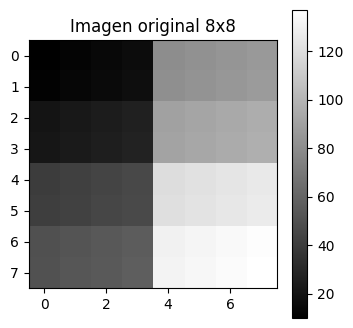

In [73]:
plt.figure(figsize=(4, 4))
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original 8x8")
plt.colorbar()
plt.show()

### 7.2. Reducción usando `reshape` y `mean`

Para dividir una imagen de `8x8` en bloques `2x2`:

```python
imagen.reshape(4, 2, 4, 2)
```

La nueva forma significa:

- 4 bloques verticales;
- 2 filas por bloque;
- 4 bloques horizontales;
- 2 columnas por bloque.

In [74]:
bloques = imagen.reshape(4, 2, 4, 2)
imagen_reducida = bloques.mean(axis=(1, 3))

print("Imagen reducida:")
print(imagen_reducida)
print("Forma:", imagen_reducida.shape)

Imagen reducida:
[[ 11.5  15.5  81.5  85.5]
 [ 21.5  25.5  91.5  95.5]
 [ 41.5  45.5 121.5 125.5]
 [ 51.5  55.5 131.5 135.5]]
Forma: (4, 4)


### 7.3. Visualización de la imagen reducida

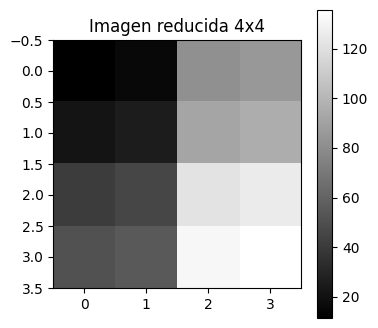

In [75]:
plt.figure(figsize=(4, 4))
plt.imshow(imagen_reducida, cmap="gray")
plt.title("Imagen reducida 4x4")
plt.colorbar()
plt.show()

### Mini reto 3

Cree una imagen binaria a partir de la imagen original:

- píxeles mayores que el promedio general reciben valor 1;
- píxeles menores o iguales al promedio reciben valor 0.

Promedio general de la imagen: 71.00

Matriz binaria resultante:
[[0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]]


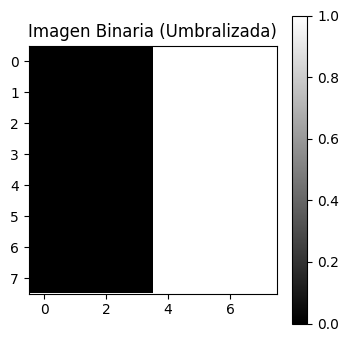

In [76]:
promedio_general = imagen.mean()

imagen_binaria = (imagen > promedio_general).astype(int)

print(f"Promedio general de la imagen: {promedio_general:.2f}\n")
print("Matriz binaria resultante:")
print(imagen_binaria)

plt.figure(figsize=(4, 4))
plt.imshow(imagen_binaria, cmap="gray")
plt.title("Imagen Binaria (Umbralizada)")
plt.colorbar()
plt.show()

# 8. Ejercicio sugerido: detección de anomalías multivariable

Este ejercicio integra varios conceptos de la sesión:

- matrices;
- operaciones por columnas;
- máscaras booleanas;
- filtrado;
- análisis numérico.

## Problema

Se tienen mediciones de sensores ambientales.  
Cada fila representa una observación y cada columna representa una variable:

`temperatura`, `humedad`, `presion`

In [77]:
mediciones = np.array([
    [18.5, 70, 1012],
    [19.2, 68, 1011],
    [20.1, 65, 1010],
    [21.0, 60, 1009],
    [20.5, 63, 1011],
    [45.0, 20, 980],   # posible anomalía
    [19.8, 66, 1012],
    [18.9, 69, 1013]
], dtype=float)

print("Mediciones:")
print(mediciones)

Mediciones:
[[  18.5   70.  1012. ]
 [  19.2   68.  1011. ]
 [  20.1   65.  1010. ]
 [  21.    60.  1009. ]
 [  20.5   63.  1011. ]
 [  45.    20.   980. ]
 [  19.8   66.  1012. ]
 [  18.9   69.  1013. ]]


### 8.1. Calcular z-score por columna

El z-score indica cuántas desviaciones estándar se aleja un dato de la media.

\[
z = \frac{x - \mu}{\sigma}
\]

In [78]:
media = mediciones.mean(axis=0)
desviacion = mediciones.std(axis=0)

z_scores = (mediciones - media) / desviacion

print("Media por columna:")
print(media)

print("\nDesviación estándar por columna:")
print(desviacion)

print("\nZ-scores:")
print(z_scores)

Media por columna:
[  22.875   60.125 1007.25 ]

Desviación estándar por columna:
[ 8.398 15.471 10.365]

Z-scores:
[[-0.521  0.638  0.458]
 [-0.438  0.509  0.362]
 [-0.33   0.315  0.265]
 [-0.223 -0.008  0.169]
 [-0.283  0.186  0.362]
 [ 2.634 -2.594 -2.629]
 [-0.366  0.38   0.458]
 [-0.473  0.574  0.555]]


### 8.2. Detectar filas anómalas

Una fila se considera anómala si al menos una de sus variables tiene:

```python
abs(z_score) > 2
```

In [79]:
mascara_anomalias = np.any(np.abs(z_scores) > 2, axis=1)

print("Máscara de anomalías:")
print(mascara_anomalias)

anomalias = mediciones[mascara_anomalias]
datos_limpios = mediciones[~mascara_anomalias]

print("\nFilas anómalas:")
print(anomalias)

print("\nDatos limpios:")
print(datos_limpios)

Máscara de anomalías:
[False False False False False  True False False]

Filas anómalas:
[[ 45.  20. 980.]]

Datos limpios:
[[  18.5   70.  1012. ]
 [  19.2   68.  1011. ]
 [  20.1   65.  1010. ]
 [  21.    60.  1009. ]
 [  20.5   63.  1011. ]
 [  19.8   66.  1012. ]
 [  18.9   69.  1013. ]]


# 9. Cierre del STV

En esta sesión se trabajó:

- unión de arrays;
- apilamiento vertical y horizontal;
- separación de variables y etiquetas;
- división de datasets;
- uso de `reshape`;
- uso de `np.newaxis`;
- KNN vectorizado;
- lectura de CSV con `np.genfromtxt`;
- procesamiento de imágenes como matrices;
- detección de anomalías usando operaciones vectorizadas.

## Pregunta final

¿Por qué NumPy permite construir algoritmos más eficientes que una solución basada solamente en ciclos `for`?

# 10. Actividad de consolidación

Seleccione dos de los siguientes retos y resuélvalos al final del notebook:

1. Agregue una nueva variable al dataset de sensores y repita la detección de anomalías.
2. Modifique el KNN para usar `k=5` y compare resultados.
3. Cree una imagen `10x10` y reduzca su resolución a `5x5`.
4. Lea otro CSV creado por usted mismo con `np.genfromtxt`.
5. Construya una matriz de distancias entre 5 puntos de prueba y 8 puntos de entrenamiento.